# Task 1
Objective: Prepare datasets

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML
import os
from PIL import Image
import colorsys

pixel_data = []

for filename in os.listdir("cat-flower"):
    if filename.lower().endswith(".png"):
        filepath = os.path.join("cat-flower", filename)
        
        with Image.open(filepath) as img:
            img = img.convert('RGB')
            width, height = img.size
            pixels = img.load()
            
            for x in range(width):
                for y in range(height):
                    r, g, b = pixels[x, y]
                    h, l, s = colorsys.rgb_to_hls(r / 255.0, g / 255.0, b / 255.0)
                    
                    h_deg = round(h * 360, 2)
                    s_pct = round(s * 100, 2)
                    l_pct = round(l * 100, 2)
                    
                    pixel_data.append({
                        'file': filename,
                        'x': x,
                        'y': y,
                        'R': r,
                        'G': g,
                        'B': b,
                        'H': h_deg,
                        'S': s_pct,
                        'L': l_pct
                    })



images_pixels = pd.DataFrame(pixel_data)


In [6]:
title = f"""
<h3 style="font-family: sans-serif;">Table of pixel colors:</h3>
"""
display(HTML(title))
display(images_pixels)

,file,x,y,R,G,B,H,S,L
0,kwiatek-76.png,0,0,90,99,30,67.83,53.49,25.29
1,kwiatek-76.png,0,1,134,151,26,68.16,70.62,34.71
2,kwiatek-76.png,0,2,132,153,30,70.24,67.21,35.88
3,kwiatek-76.png,0,3,141,158,81,73.25,32.22,46.86
4,kwiatek-76.png,0,4,120,140,36,71.54,59.09,34.51
...,...,...,...,...,...,...,...,...,...
1319995,kwiatek-53.png,99,95,3,3,3,0.00,0.00,1.18
1319996,kwiatek-53.png,99,96,4,4,4,0.00,0.00,1.57
1319997,kwiatek-53.png,99,97,5,5,3,60.00,25.00,1.57
1319998,kwiatek-53.png,99,98,7,10,5,96.00,33.33,2.94


In [7]:
cats_pixels = images_pixels[images_pixels['file'].str.startswith('kotek')]
unique_colors_cats = cats_pixels.groupby(['R', 'G', 'B', 'H', 'S', 'L']).size().reset_index(name='count')
unique_colors_cats = unique_colors_cats.reset_index(drop=True)


flowers_pixels = images_pixels[images_pixels['file'].str.startswith('kwiatek')]
unique_colors_flowers = flowers_pixels.groupby(['R', 'G', 'B', 'H', 'S', 'L']).size().reset_index(name='count')
unique_colors_flowers = unique_colors_flowers.reset_index(drop=True)


max_RGB = unique_colors_cats[['R', 'G', 'B']].max(axis=1)
unique_colors_cats['is_dominating_R'] = (unique_colors_cats['R'] == max_RGB).astype(int)
unique_colors_cats['is_dominating_G'] = (unique_colors_cats['G'] == max_RGB).astype(int)
unique_colors_cats['is_dominating_B'] = (unique_colors_cats['B'] == max_RGB).astype(int)
unique_colors_cats['is_cold'] = ((unique_colors_cats['H'] >= 180) & (unique_colors_cats['H'] <= 270)).astype(int)
unique_colors_cats['is_saturated'] = (unique_colors_cats['S'] > 70).astype(int)

max_RGB = unique_colors_flowers[['R', 'G', 'B']].max(axis=1)
unique_colors_flowers['is_dominating_R'] = (unique_colors_flowers['R'] == max_RGB).astype(int)
unique_colors_flowers['is_dominating_G'] = (unique_colors_flowers['G'] == max_RGB).astype(int)
unique_colors_flowers['is_dominating_B'] = (unique_colors_flowers['B'] == max_RGB).astype(int)
unique_colors_flowers['is_cold'] = ((unique_colors_flowers['H'] >= 180) & (unique_colors_flowers['H'] <= 270)).astype(int)
unique_colors_flowers['is_saturated'] = (unique_colors_flowers['S'] > 70).astype(int)

In [8]:
title_cats = f"""
<h3 style="font-family: sans-serif;">Table of unique colors (cats):</h3>
"""
display(HTML(title_cats))
display(unique_colors_cats)

title_flowers = f"""
<h3 style="font-family: sans-serif;">Table of unique colors (flowers):</h3>
"""
display(HTML(title_flowers))
display(unique_colors_flowers)

,R,G,B,H,S,L,count,is_dominating_R,is_dominating_G,is_dominating_B,is_cold,is_saturated
0,0,0,0,0.0,0.0,0.00,240,1,1,1,0,0
1,0,0,1,240.0,100.0,0.20,13,0,0,1,1,1
2,0,0,2,240.0,100.0,0.39,6,0,0,1,1,1
3,0,0,3,240.0,100.0,0.59,2,0,0,1,1,1
4,0,0,4,240.0,100.0,0.78,2,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
419038,255,255,251,60.0,100.0,99.22,48,1,1,0,0,1
419039,255,255,252,60.0,100.0,99.41,21,1,1,0,0,1
419040,255,255,253,60.0,100.0,99.61,54,1,1,0,0,1
419041,255,255,254,60.0,100.0,99.80,47,1,1,0,0,1


,R,G,B,H,S,L,count,is_dominating_R,is_dominating_G,is_dominating_B,is_cold,is_saturated
0,0,0,0,0.0,0.0,0.00,4462,1,1,1,0,0
1,0,0,1,240.0,100.0,0.20,325,0,0,1,1,1
2,0,0,2,240.0,100.0,0.39,62,0,0,1,1,1
3,0,0,3,240.0,100.0,0.59,16,0,0,1,1,1
4,0,0,4,240.0,100.0,0.78,3,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
522596,255,255,251,60.0,100.0,99.22,54,1,1,0,0,1
522597,255,255,252,60.0,100.0,99.41,51,1,1,0,0,1
522598,255,255,253,60.0,100.0,99.61,82,1,1,0,0,1
522599,255,255,254,60.0,100.0,99.80,92,1,1,0,0,1


(-0.5, 99.5, 99.5, -0.5)

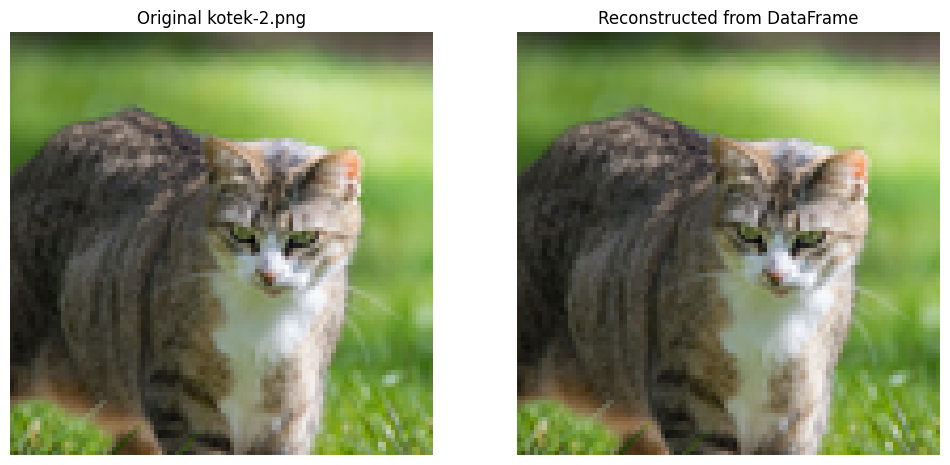

In [9]:
# testing if we can reconstruct the image from the DataFrame
test_image_pixels = images_pixels[images_pixels['file'] == 'kotek-2.png']
width = height = 100
test_image = np.zeros((height, width, 3), dtype=np.uint8)
test_image[test_image_pixels['y'], test_image_pixels['x'], 0] = test_image_pixels['R']
test_image[test_image_pixels['y'], test_image_pixels['x'], 1] = test_image_pixels['G']
test_image[test_image_pixels['y'], test_image_pixels['x'], 2] = test_image_pixels['B']

test_image_photo = Image.open('cat-flower/kotek-2.png').convert('RGB')


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(test_image_photo)
axes[0].set_title(f"Original kotek-2.png")
axes[0].axis('off')

axes[1].imshow(test_image)
axes[1].set_title(f"Reconstructed from DataFrame")
axes[1].axis('off')

# Task 2
Objective: Explore data using graphs and descriptive statistics.

In [10]:
# number of unique colors in each image
unique_pixels = images_pixels.drop_duplicates(subset=['file', 'R', 'G', 'B'])
images_colors = unique_pixels.groupby('file').size().reset_index(name='unique_colors')

In [11]:
title_colors = f"""
<h3 style="font-family: sans-serif;">Number of unique colors in each image:</h3>
"""
display(HTML(title_colors))
display(images_colors)

title_colors_desc = f"""<h3 style="font-family: sans-serif;">Descriptive statistics of unique colors:</h3>
"""
display(HTML(title_colors_desc))

display(images_colors.describe())

,file,unique_colors
0,kotek-0.png,9177
1,kotek-1.png,9151
2,kotek-10.png,7918
3,kotek-11.png,8913
4,kotek-12.png,9648
...,...,...
127,kwiatek-74.png,5707
128,kwiatek-75.png,9795
129,kwiatek-76.png,9481
130,kwiatek-8.png,7893


,unique_colors
count,132.000000
mean,8649.393939
std,1163.402865
min,4538.000000
25%,7988.000000
50%,9072.500000
75%,9521.250000
max,9911.000000


* **Minimum number** of unique colors (4538) shows that even the simpliest image still contains thousands of different shades.

* **Maximum number** is very close to 10000 what shows that most complicated image has almost every pixel of different shade.

* **Mean** (~8600) tells that on average one image uses unique colors for 86% of pixels.

* **Median** (9072.5) tells that half of the images have over 90% of pixels as unique colors.

* **Standard deviation** (~1000) demonstrates moderate, consistent spread.

In [12]:
cat_images_color_count = images_colors[images_colors['file'].str.startswith('kotek')]
flowers_images_color_count = images_colors[images_colors['file'].str.startswith('kwiatek')]

title_flowers_desc = f"""<h3 style="font-family: sans-serif;">Descriptive statistics of unique colors (flowers):</h3>
"""
display(HTML(title_flowers_desc))
display(flowers_images_color_count.describe())

title_cats_desc = f"""<h3 style="font-family: sans-serif;">Descriptive statistics of unique colors (cats):</h3>
"""
display(HTML(title_cats_desc))
display(cat_images_color_count.describe())

,unique_colors
count,77.000000
mean,8251.090909
std,1308.527217
min,4538.000000
25%,7348.000000
50%,8768.000000
75%,9315.000000
max,9881.000000


,unique_colors
count,55.000000
mean,9207.018182
std,575.119295
min,7339.000000
25%,8943.000000
50%,9387.000000
75%,9609.000000
max,9911.000000


there are 77 images of flowers and 55 images of cats.

In [13]:
# function to create a color square for visualization
def draw_color_square(row):
    r, g, b = row['R'], row['G'], row['B']
    return f'<div style="width: 25px; height: 25px; background-color: rgb({r}, {g}, {b}); border: 1px solid #000; border-radius: 3px;"></div>'

In [14]:
# 5 top colors in cats and flowers
unique_colors_cats_head = unique_colors_cats.sort_values('count', ascending=False).head(5).copy()
unique_colors_cats_head['color'] = unique_colors_cats_head.apply(draw_color_square, axis=1)
unique_colors_flowers_head = unique_colors_flowers.sort_values('count', ascending=False).head(5).copy()
unique_colors_flowers_head['color'] = unique_colors_flowers_head.apply(draw_color_square, axis=1)

In [15]:
title_cats_uni = f"""<h3 style="font-family: sans-serif;">Top 5 unique colors (cats):</h3>
"""
display(HTML(title_cats_uni))
display(HTML(unique_colors_cats_head.to_html(escape=False)))

title_cats_hsl_desc = f"""<h3 style="font-family: sans-serif;">Descriptive statistics of HSL (cats):</h3>
"""
display(HTML(title_cats_hsl_desc))
display(unique_colors_cats[['H', 'S', 'L']].describe())

title_flowers_uni = f"""<h3 style="font-family: sans-serif;">Top 5 unique colors (flowers):</h3>
"""
display(HTML(title_flowers_uni))
display(HTML(unique_colors_flowers_head.to_html(escape=False)))

title_flowers_hsl_desc = f"""<h3 style="font-family: sans-serif;">Descriptive statistics of HSL (flowers):</h3>
"""
display(HTML(title_flowers_hsl_desc))
display(unique_colors_flowers[['H', 'S', 'L']].describe())

,R,G,B,H,S,L,count,is_dominating_R,is_dominating_G,is_dominating_B,is_cold,is_saturated,color
419042,255,255,255,0.0,0.00,100.00,538,1,1,1,0,0,
418493,254,254,254,0.0,0.00,99.61,308,1,1,1,0,0,
0,0,0,0,0.0,0.00,0.00,240,1,1,1,0,0,
418238,253,253,253,0.0,0.00,99.22,156,1,1,1,0,0,
416118,246,245,241,48.0,21.74,95.49,78,1,0,0,0,0,


,H,S,L
count,419043.000000,419043.000000,419043.000000
mean,91.889711,33.964362,43.296755
std,65.694036,21.518548,19.448374
min,0.000000,0.000000,0.000000
25%,50.000000,16.740000,29.220000
50%,80.000000,31.090000,41.960000
75%,104.000000,47.220000,55.690000
max,359.150000,100.000000,100.000000


,R,G,B,H,S,L,count,is_dominating_R,is_dominating_G,is_dominating_B,is_cold,is_saturated,color
0,0,0,0,0.0,0.0,0.00,4462,1,1,1,0,0,
522600,255,255,255,0.0,0.0,100.00,1331,1,1,1,0,0,
217,1,1,1,0.0,0.0,0.39,894,1,1,1,0,0,
502,2,2,2,0.0,0.0,0.78,489,1,1,1,0,0,
729,3,3,3,0.0,0.0,1.18,452,1,1,1,0,0,


,H,S,L
count,522601.000000,522601.000000,522601.000000
mean,104.888934,49.862328,42.038394
std,112.129852,28.381060,19.539545
min,0.000000,0.000000,0.000000
25%,32.000000,26.190000,27.250000
50%,61.880000,45.610000,41.370000
75%,105.000000,74.420000,54.900000
max,359.760000,100.000000,100.000000


## Saturation

*   **Minimum (0.0%) and Maximum (100.0%):** Both cats and flowers span the entire possible range of saturation, meaning both datasets contain colorless pixels (0%) as well as very saturated pigments (100%).
*   **Mean:** Flowers are significantly more vibrant on average (~49.9%) compared to cats (~34.0%). This is expected as flowers naturally contain richer colors.
*   **Median:** 45.6% for flowers and 31.1% for cats confirms that the typical flower is far more saturated than the typical cat.
*   **Standard Deviation:** Flowers have a higher spread in saturation (~28.4%) than cats (~21.5%), indicating that flower images have a wider mix of both pale and heavily saturated pixels, whereas cats remain mostly desaturated.

## Lightness

*   **Minimum (0.0%) and Maximum (100.0%):** Both categories hit the absolute extremes, meaning both sets of images contain black shadows (0%) and white highlights (100%).
*   **Mean:** Despite the differences in saturation, lightness is almost identical, with cats averaging ~43.3% and flowers ~42.0%. 
*   **Median:** The median lightness is also  similar (cats at ~42.0%, flowers at ~41.4%)
*   **Standard Deviation:** The spread in lightness is the same in both categories (~19.5%), reflecting consistent general lighting conditions across the dataset.

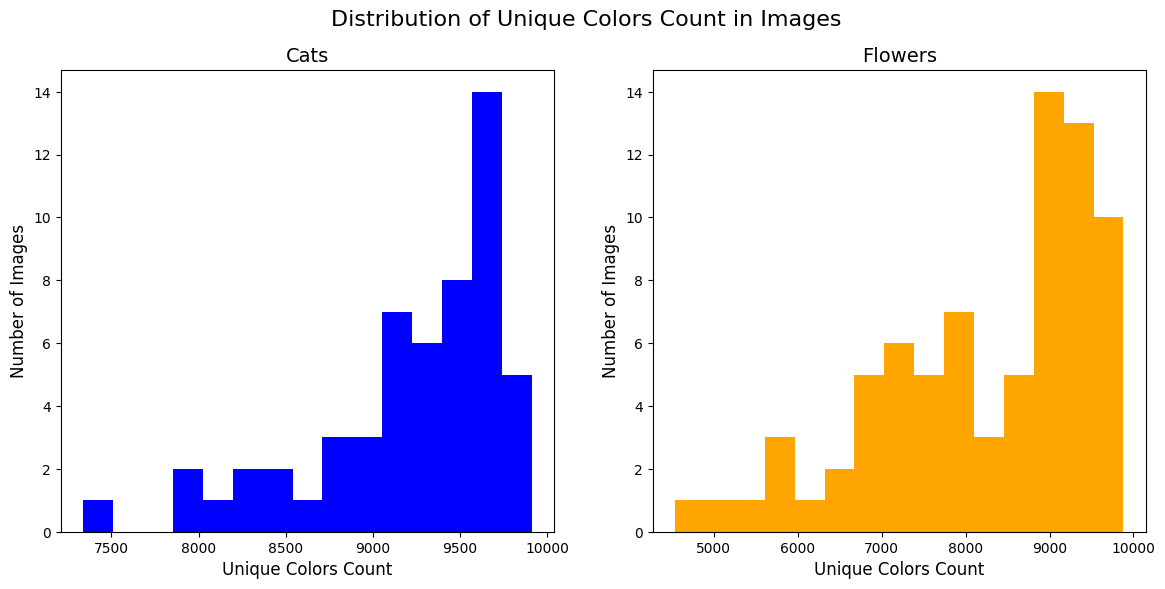

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.hist(cat_images_color_count['unique_colors'], bins=15, color='blue')
ax2.hist(flowers_images_color_count['unique_colors'], bins=15, color='orange')
ax1.set_title('Cats', fontsize=14)
ax1.set_xlabel('Unique Colors Count', fontsize=12)
ax1.set_ylabel('Number of Images', fontsize=12)
ax2.set_title('Flowers', fontsize=14)
ax2.set_xlabel('Unique Colors Count', fontsize=12)
ax2.set_ylabel('Number of Images', fontsize=12)
fig.suptitle('Distribution of Unique Colors Count in Images', fontsize=16)
plt.show()

The histograms confirm that most of the images in the dataset are composed of a high number of unique colors. It is also noticeable that the number of unique colors in cat images varies less and remains consistently high. This may be because cat photos capture a lot of fine details, such as individual strands of fur or whiskers. The graph of unique color counts for flower images has a thicker tail to the left. This is likely because flowers do not usually present as many sharp details.

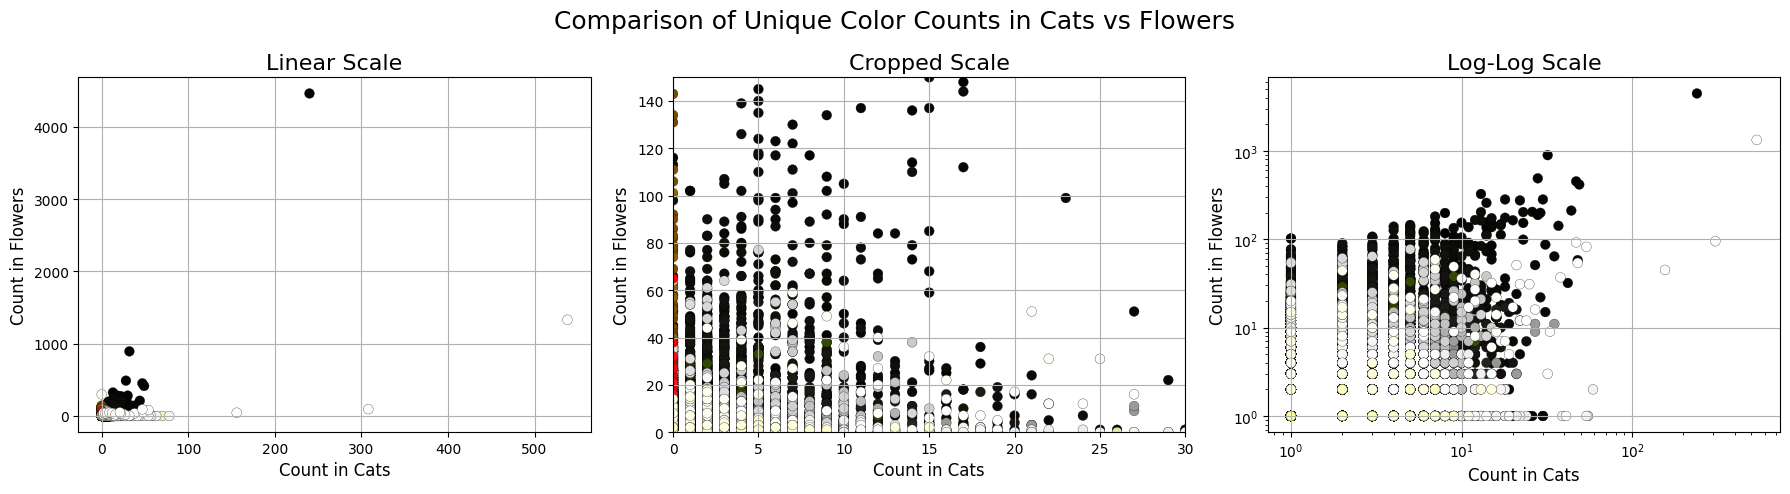

In [17]:
key_columns = [col for col in unique_colors_cats.columns if col != 'count']
unique_colors_cats_flowers = pd.merge(unique_colors_cats, unique_colors_flowers, on=key_columns, how='outer', suffixes=('_cats', '_flowers')).fillna(0)
colors_array = unique_colors_cats_flowers[['R', 'G', 'B']].values / 255.0
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(
    unique_colors_cats_flowers['count_cats'],
    unique_colors_cats_flowers['count_flowers'],
    c=colors_array,
    edgecolors='black',
    linewidths=0.2, 
    s=50, 
)
axes[0].set_title('Linear Scale', fontsize=16)
axes[0].set_xlabel('Count in Cats', fontsize=12)
axes[0].set_ylabel('Count in Flowers', fontsize=12)
axes[0].grid(True)

axes[1].set_xlim(0, 30)
axes[1].set_ylim(0, 150)
axes[1].scatter(
    unique_colors_cats_flowers['count_cats'],
    unique_colors_cats_flowers['count_flowers'],
    c=colors_array,
    edgecolors='black',
    linewidths=0.2,
    s=50,
)
axes[1].set_title('Cropped Scale', fontsize=16)
axes[1].set_xlabel('Count in Cats', fontsize=12)
axes[1].set_ylabel('Count in Flowers', fontsize=12)
axes[1].grid(True)


axes[2].scatter(
    unique_colors_cats_flowers['count_cats'],
    unique_colors_cats_flowers['count_flowers'],
    c=colors_array,
    edgecolors='black',
    linewidths=0.2,
    s=50,
)
axes[2].set_title('Log-Log Scale', fontsize=16)
axes[2].set_xlabel('Count in Cats', fontsize=12)
axes[2].set_ylabel('Count in Flowers', fontsize=12)
axes[2].grid(True)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
fig.suptitle('Comparison of Unique Color Counts in Cats vs Flowers', fontsize=18)
plt.tight_layout()
plt.show()

Across all graphs, it is evident that the vast majority of unique colors are shades of gray, ranging from white to black.

The first graph is barely readable due to clustering, but it clearly shows the outliers; specifically two colors (black and white) that are the most common across the entire dataset.

The second graph is a zoomed-in window of the first one, making it much more readable. Here, we can see even more clearly that shades of gray predominate the dataset. There are also some visible shades of red in the flower images, which are not present in the cat images.

The third graph presents all the colors using a logarithmic scale so the entire distribution fits. This view reveals a slight positive trend: if a color is  popular in one dataset, it tends to be popular in the other as well.

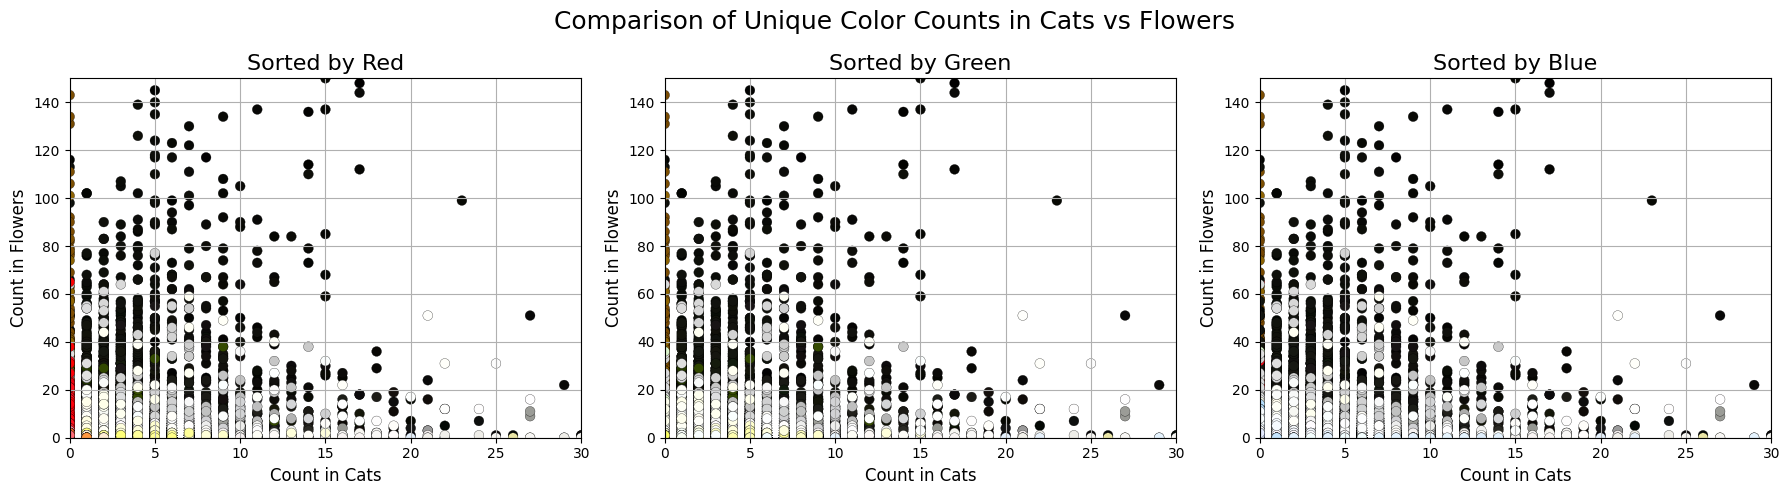

In [18]:
s = unique_colors_cats_flowers.sort_values(by=['R'], ascending=True).reset_index(drop=True)
scolors_array = s[['R', 'G', 'B']].values / 255.0
m = unique_colors_cats_flowers.sort_values(by=['G'], ascending=True).reset_index(drop=True)
mcolors_array = m[['R', 'G', 'B']].values / 255.0
p = unique_colors_cats_flowers.sort_values(by=['B'], ascending=True).reset_index(drop=True)
pcolors_array = p[['R', 'G', 'B']].values / 255.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].set_xlim(0, 30)
axes[0].set_ylim(0, 150)
axes[0].scatter(
    s['count_cats'],
    s['count_flowers'],
    c=scolors_array,
    edgecolors='black',
    linewidths=0.2, 
    s=50, 
)
axes[0].set_title('Sorted by Red', fontsize=16)
axes[0].set_xlabel('Count in Cats', fontsize=12)
axes[0].set_ylabel('Count in Flowers', fontsize=12)
axes[0].grid(True)

axes[1].set_xlim(0, 30)
axes[1].set_ylim(0, 150)
axes[1].scatter(
    m['count_cats'],
    m['count_flowers'],
    c=mcolors_array,
    edgecolors='black',
    linewidths=0.2,
    s=50,
)
axes[1].set_title('Sorted by Green', fontsize=16)
axes[1].set_xlabel('Count in Cats', fontsize=12)
axes[1].set_ylabel('Count in Flowers', fontsize=12)
axes[1].grid(True)

axes[2].set_xlim(0, 30)
axes[2].set_ylim(0, 150)
axes[2].scatter(
    p['count_cats'],
    p['count_flowers'],
    c=pcolors_array,
    edgecolors='black',
    linewidths=0.2,
    s=50,
)
axes[2].set_title('Sorted by Blue', fontsize=16)
axes[2].set_xlabel('Count in Cats', fontsize=12)
axes[2].set_ylabel('Count in Flowers', fontsize=12)
axes[2].grid(True)

fig.suptitle('Comparison of Unique Color Counts in Cats vs Flowers', fontsize=18)
plt.tight_layout()
plt.show()

These three graphs sort the data by R, G, and B channels to test how drawing order affects the visibility of overlapping points.

All three variations appear similar, proving that the overall distribution of colors is independent of the order in which the data is displayed.

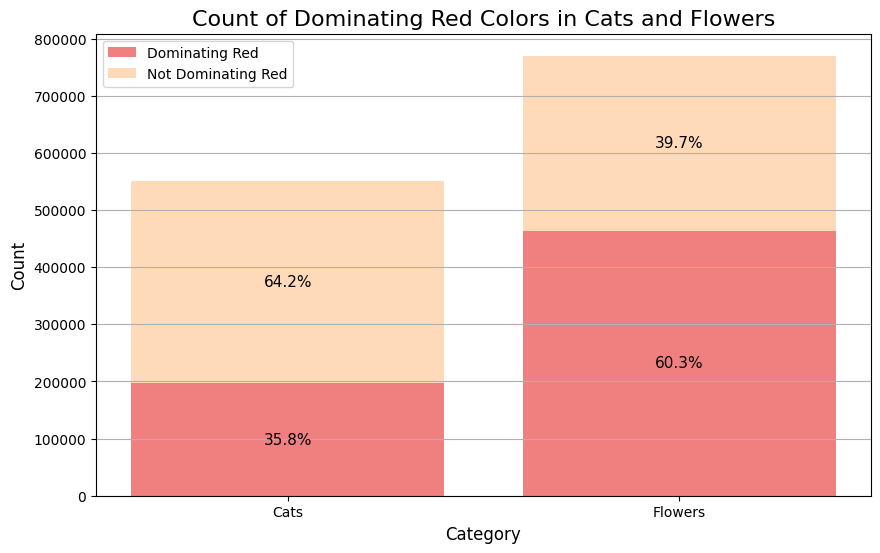

In [19]:
dom_R_cats = unique_colors_cats[unique_colors_cats['is_dominating_R'] == 1].sum(axis=0)['count']
ndom_R_cats = unique_colors_cats[unique_colors_cats['is_dominating_R'] == 0].sum(axis=0)['count']
dom_R_flowers = unique_colors_flowers[unique_colors_flowers['is_dominating_R'] == 1].sum(axis=0)['count']
ndom_R_flowers = unique_colors_flowers[unique_colors_flowers['is_dominating_R'] == 0].sum(axis=0)['count']

total_cats = dom_R_cats + ndom_R_cats
total_flowers = dom_R_flowers + ndom_R_flowers
totals = [total_cats, total_flowers]

plt.figure(figsize=(10, 6))
bottom = plt.bar(['Cats', 'Flowers'], [dom_R_cats, dom_R_flowers], color='lightcoral', label='Dominating Red')
top = plt.bar(['Cats', 'Flowers'], [ndom_R_cats, ndom_R_flowers], bottom=[dom_R_cats, dom_R_flowers], color='peachpuff', label='Not Dominating Red')
plt.title('Count of Dominating Red Colors in Cats and Flowers', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.grid(axis='y')

labels_dom = [f"{(val / tot) * 100:.1f}%" for val, tot in zip([dom_R_cats, dom_R_flowers], totals)]
labels_ndom = [f"{(val / tot) * 100:.1f}%" for val, tot in zip([ndom_R_cats, ndom_R_flowers], totals)]


plt.bar_label(bottom, labels=labels_dom, label_type='center', fontsize=11, color='black')
plt.bar_label(top, labels=labels_ndom, label_type='center', fontsize=11, color='black')
plt.show()

The stacked bar chart reveals that the `is_dominating_R` variable is very frequently present in flower images (over 60%). In cat images, red dominates in only about 35% of pixels. This is because flowers often possess vibrant red hues, while cats are made up of more neutral, earthy colors.

# Task 3
Objective: Choose the best variables and algorithm for clustering to reduce colors.

In [20]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
sample = unique_colors_cats_flowers.sample(200)
colors_array = sample.apply(lambda row: f'rgb({int(row["R"])}, {int(row["G"])}, {int(row["B"])})', axis=1)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=("RGB Space", "HSL Space")
)
fig.add_trace(
    go.Scatter3d(
        x=sample['R'], 
        y=sample['G'], 
        z=sample['B'],
        mode='markers',
        marker=dict(color=colors_array, size=5, opacity=0.8),
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter3d(
        x=sample['H'], 
        y=sample['S'], 
        z=sample['L'],
        mode='markers',
        marker=dict(color=colors_array, size=5, opacity=0.8),
    ),
    row=1, col=2
)
fig.update_layout(
    title_text="Comparison of Color Distributions in RGB and HSL Spaces (in cats images)",
    title_x=0.5,
    height=600,
    width=1200,
    showlegend=False,
    
    scene=dict(
        xaxis_title='Red', 
        yaxis_title='Green', 
        zaxis_title='Blue'
    ),
    scene2=dict(
        xaxis_title='Hue', 
        yaxis_title='Saturation', 
        zaxis_title='Lightness'
    )
)

fig.show()

In the RGB graph of sample of 200 colors, we can see that colors that look similar to the human eye are naturally clustered together, properly taking into account both brightness and hue. On the HSL graph, however, several problems emerge. First, it requires mathematical manipulation just to make Hue 0 (red) and Hue 359 (also red) close to each other. Second, even after fixing that, dark colors that are indistinguishable to the human eye are pushed far apart. Finally, there are very few data points around Hue 250; this empty space turns the points in that area into outliers, which is highly detrimental to clustering.

To have better comparsion, let's perform clustering on random 5 images from dataset using RGB and HSL variables and visually compare results.

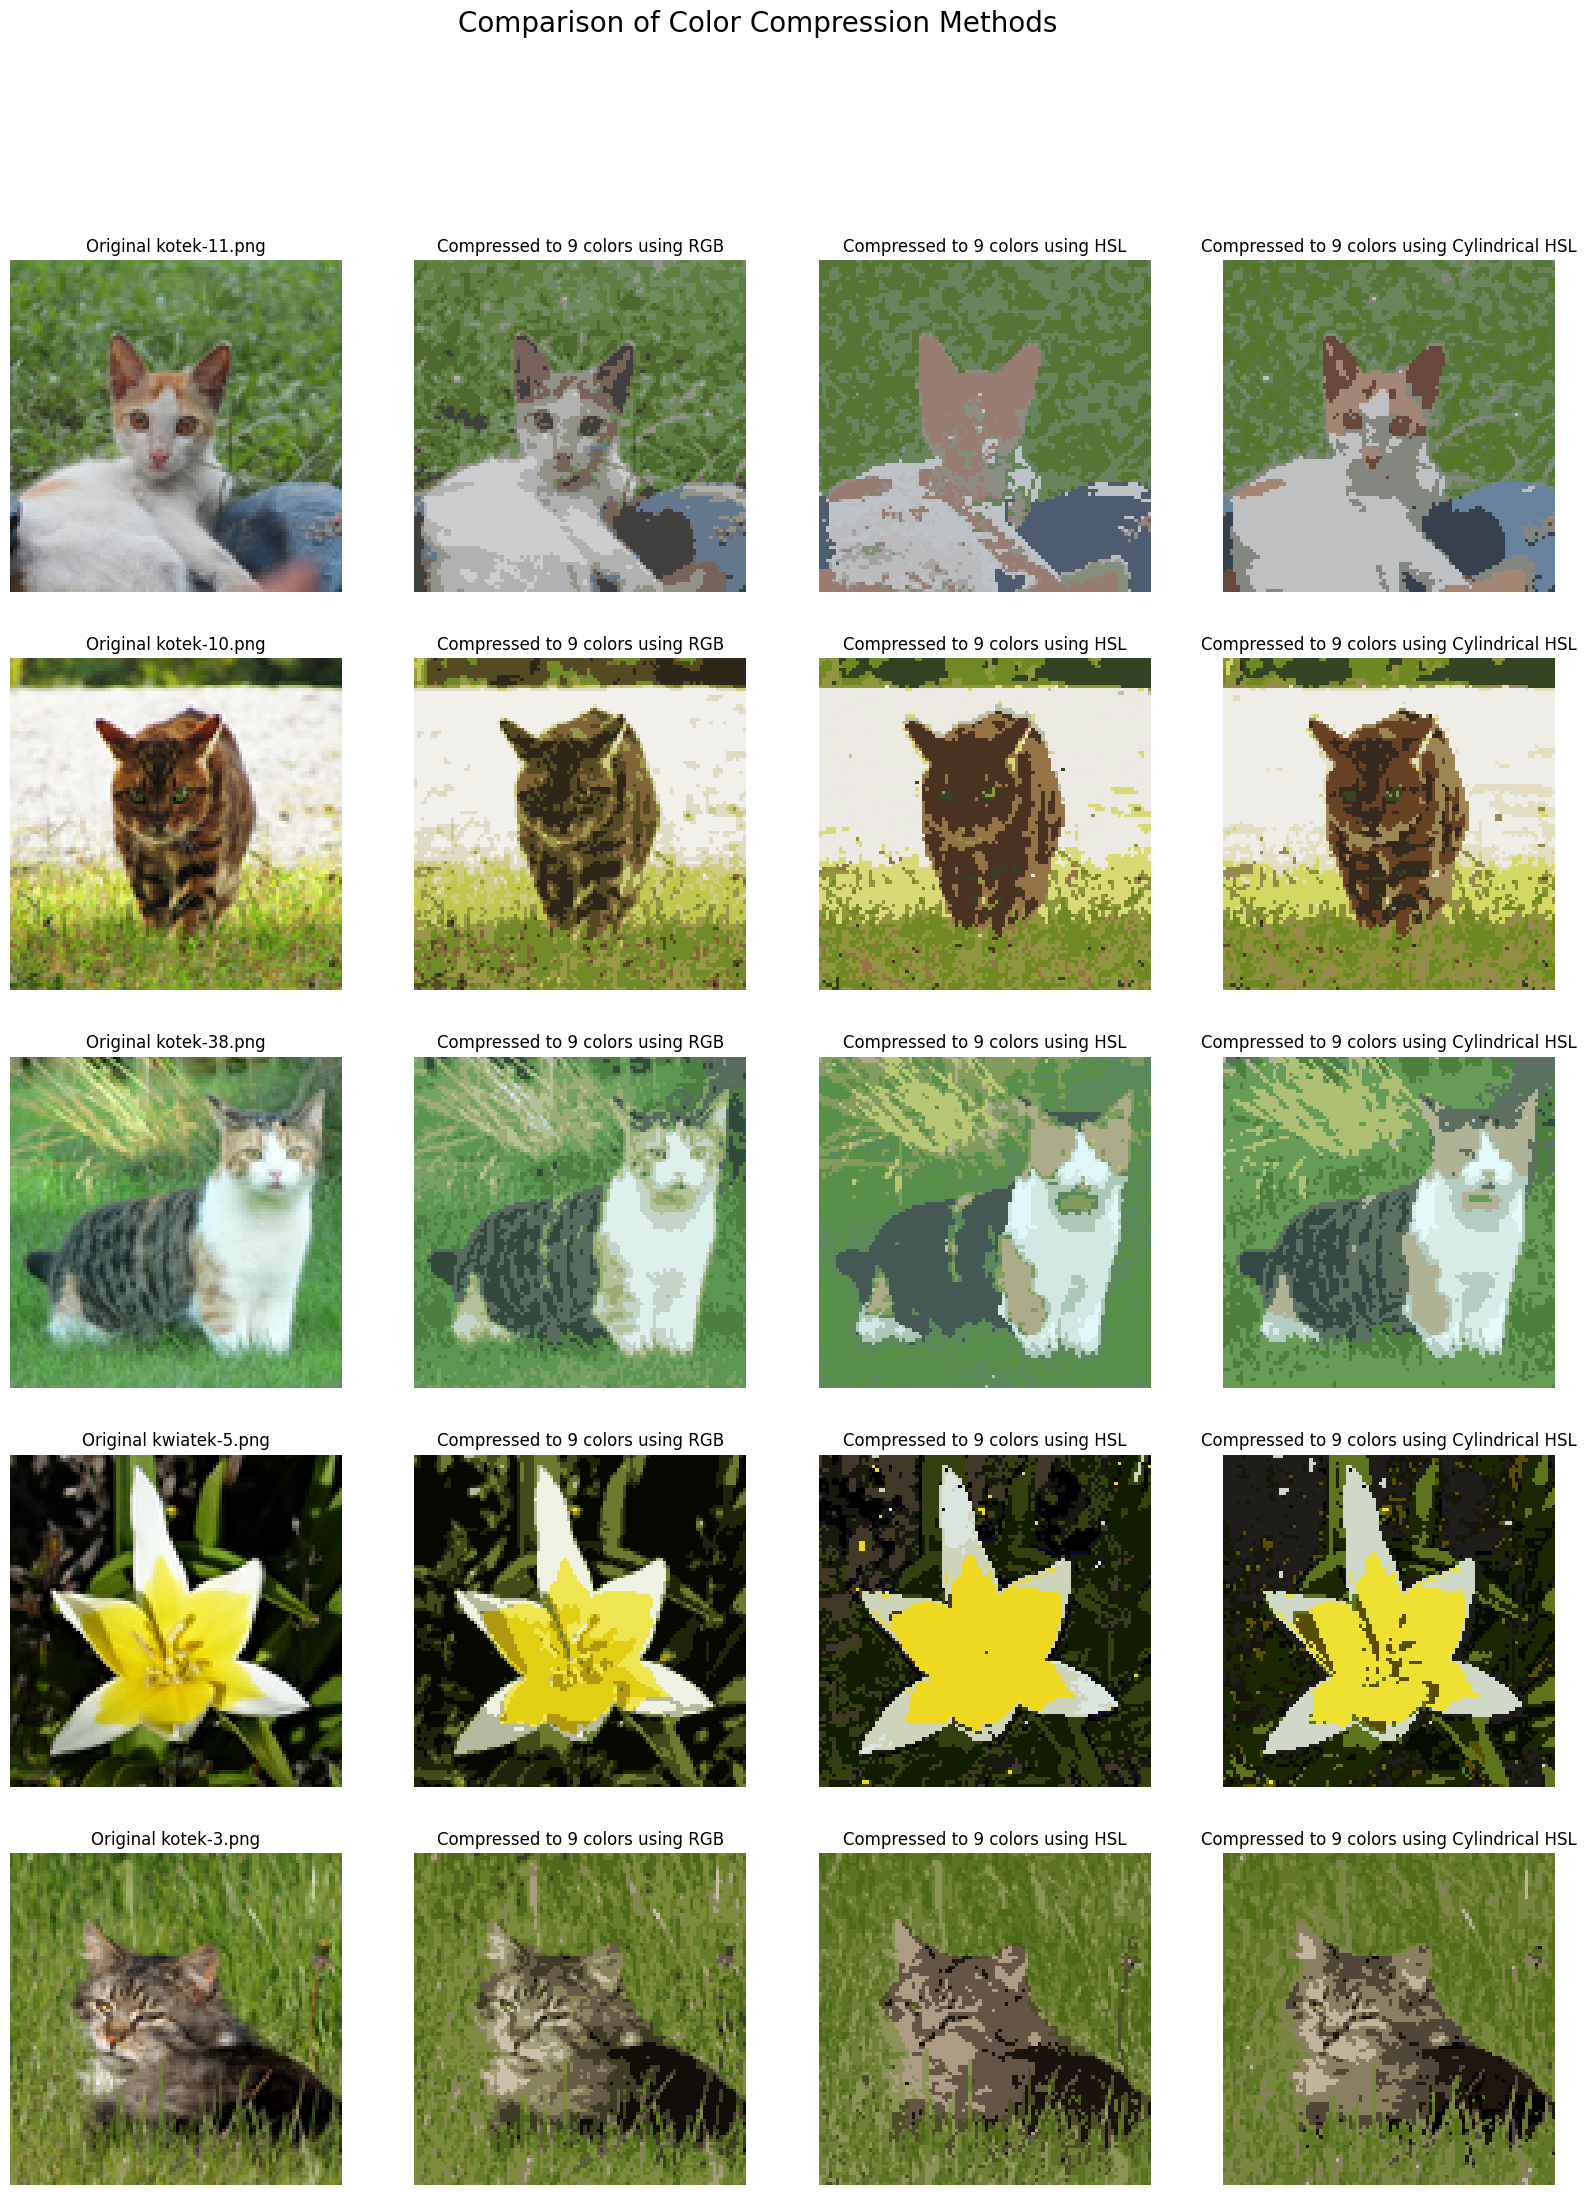

In [36]:
import warnings
from numpy.random.mtrand import seed
from sklearn.cluster import KMeans
warnings.filterwarnings('ignore', category=RuntimeWarning)

uni = images_pixels['file'].unique()
k = 9
ims = uni[40:45]
for i, image in enumerate(ims):
    mask = images_pixels['file'] == image

    # --- RGB ---
    X_rgb = images_pixels.loc[mask, ['R', 'G', 'B']].values
    
    model_rgb = KMeans(n_clusters=k, random_state=42, n_init='auto')
    model_rgb.fit(X_rgb)
    
    palette_rgb = model_rgb.cluster_centers_.astype('uint8')
    new_colors_array_rgb = palette_rgb[model_rgb.labels_]
    images_pixels.loc[mask, 'newR'] = new_colors_array_rgb[:, 0]
    images_pixels.loc[mask, 'newG'] = new_colors_array_rgb[:, 1]
    images_pixels.loc[mask, 'newB'] = new_colors_array_rgb[:, 2]

    # --- HSL ---
    X_hsl = images_pixels.loc[mask, ['H', 'S', 'L']].values
    model_hsl = KMeans(n_clusters=k, random_state=42, n_init='auto')
    model_hsl.fit(X_hsl)

    palette_hsl = model_hsl.cluster_centers_.astype('uint8')
    palette_rgb_from_hsl = np.array([colorsys.hls_to_rgb(h/360, l/100, s/100) for h, s, l in palette_hsl]) * 255
    new_colors_array_hsl = palette_rgb_from_hsl[model_hsl.labels_]
    images_pixels.loc[mask, 'newR_hsl'] = new_colors_array_hsl[:, 0]
    images_pixels.loc[mask, 'newG_hsl'] = new_colors_array_hsl[:, 1]
    images_pixels.loc[mask, 'newB_hsl'] = new_colors_array_hsl[:, 2]

    # --- HSL (Cylindrical Projection) ---
    X_hsl_raw = images_pixels.loc[mask, ['H', 'S', 'L']].values.astype(float)
    
    H_rad = np.radians(X_hsl_raw[:, 0])
    S_scaled = X_hsl_raw[:, 1] / 100.0
    L_scaled = X_hsl_raw[:, 2] / 100.0

    X_cyl = np.zeros_like(X_hsl_raw)
    X_cyl[:, 0] = S_scaled * np.cos(H_rad)
    X_cyl[:, 1] = S_scaled * np.sin(H_rad)
    X_cyl[:, 2] = L_scaled

    model_cyl = KMeans(n_clusters=k, random_state=1104, n_init='auto')
    model_cyl.fit(X_cyl)

    palette_rgb_from_cyl = []
    for x, y, z in model_cyl.cluster_centers_:
        s = np.sqrt(x**2 + y**2)
        h_rad = np.arctan2(y, x)
        h_deg = np.degrees(h_rad) % 360
        h_scaled = h_deg / 360.0
        
        s = np.clip(s, 0.0, 1.0)
        l_scaled = np.clip(z, 0.0, 1.0)

        rgb = colorsys.hls_to_rgb(h_scaled, l_scaled, s)
        palette_rgb_from_cyl.append(rgb)

    palette_rgb_from_cyl = np.array(palette_rgb_from_cyl) * 255
    
    new_colors_array_cyl = palette_rgb_from_cyl[model_cyl.labels_]
    images_pixels.loc[mask, 'newR_cyl'] = new_colors_array_cyl[:, 0]
    images_pixels.loc[mask, 'newG_cyl'] = new_colors_array_cyl[:, 1]
    images_pixels.loc[mask, 'newB_cyl'] = new_colors_array_cyl[:, 2]



fig, axes = plt.subplots(5, 4, figsize=(20, 25))
for i, image in enumerate(ims):
    mask = images_pixels['file'] == image
    
    width = height = 100
    test_image_new_colors_rgb = np.zeros((height, width, 3), dtype=np.uint8)
    pixels = images_pixels.loc[mask, ['x', 'y']]

    test_image_new_colors_rgb[pixels['y'], pixels['x'], 0] = images_pixels.loc[mask, 'newR']
    test_image_new_colors_rgb[pixels['y'], pixels['x'], 1] = images_pixels.loc[mask, 'newG']
    test_image_new_colors_rgb[pixels['y'], pixels['x'], 2] = images_pixels.loc[mask, 'newB']

    test_image_new_colors_hsl = np.zeros((height, width, 3), dtype=np.uint8)
    test_image_new_colors_hsl[pixels['y'], pixels['x'], 0] = images_pixels.loc[mask, 'newR_hsl']
    test_image_new_colors_hsl[pixels['y'], pixels['x'], 1] = images_pixels.loc[mask, 'newG_hsl']
    test_image_new_colors_hsl[pixels['y'], pixels['x'], 2] = images_pixels.loc[mask, 'newB_hsl']

    test_image_new_colors_cyl = np.zeros((height, width, 3), dtype=np.uint8)
    test_image_new_colors_cyl[pixels['y'], pixels['x'], 0] = images_pixels.loc[mask, 'newR_cyl']
    test_image_new_colors_cyl[pixels['y'], pixels['x'], 1] = images_pixels.loc[mask, 'newG_cyl']
    test_image_new_colors_cyl[pixels['y'], pixels['x'], 2] = images_pixels.loc[mask, 'newB_cyl']


    test_image_photo = Image.open(f'cat-flower/{image}').convert('RGB')

    axes[i, 0].imshow(test_image_photo)
    axes[i, 0].set_title(f"Original {image}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(test_image_new_colors_rgb)
    axes[i, 1].set_title(f"Compressed to {k} colors using RGB")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(test_image_new_colors_hsl)
    axes[i, 2].set_title(f"Compressed to {k} colors using HSL")
    axes[i, 2].axis('off')

    axes[i, 3].imshow(test_image_new_colors_cyl)
    axes[i, 3].set_title(f"Compressed to {k} colors using Cylindrical HSL")
    axes[i, 3].axis('off')

fig.suptitle('Comparison of Color Compression Methods', fontsize=20)
# plt.tight_layout()
plt.show()

From this comparison, using arbitrarily chosen images, we can make the following observations:

It is crucial for HSL training to properly scale the data and manipulate the coordinates.

The reconstruction from the RGB training is the most similar to the original image to the human eye.

The reconstruction from the HSL training keeps the colors the same (in terms of hue), but it is not sensitive to shades or lighting, making it look less natural to the human eye

Therefore I will be using RGB values for training from now on.

In [253]:
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn_extra.cluster import KMedoids
import seaborn as sns
warnings.filterwarnings('ignore', category=RuntimeWarning)
results = []
uni = images_pixels['file'].unique()
seeds = [1104, 12041, 130412, 140413, 150414]

for image in uni: 
    print(f"\n--- Processing: {image} ---")
    
    pixels = images_pixels[images_pixels['file'] == image].copy()
    X = pixels[['R', 'G', 'B']]
    
    for k in range(5, 21):
        print(f"  k={k}...")
        
        for algo_name in ['K-Means', 'K-Medians']:
            
            sil_scores = []
            chi_scores = []
            
            for run in range(5):
                seed = seeds[run]
                
                if algo_name == 'K-Means':
                    model = KMeans(n_clusters=k, random_state=seed, n_init='auto', max_iter=300)
                else:
                    model = KMedoids(n_clusters=k, random_state=seed, metric='manhattan', init='k-medoids++')
                
                model.fit(X)
                
                chi = calinski_harabasz_score(X, model.labels_)
                
                # sil = silhouette_score(X, model.labels_, sample_size=2000, random_state=seed)
                sil = silhouette_score(X, model.labels_) 
                
                chi_scores.append(chi)
                sil_scores.append(sil)
                
            mean_chi = np.mean(chi_scores)
            mean_sil = np.mean(sil_scores)
            
            results.append({
                'Image': image,
                'Algorithm': algo_name,
                'k': k,
                'Mean_CHI': mean_chi,
                'Mean_Silhouette': mean_sil
            })

df_results = pd.DataFrame(results)


--- Processing: kwiatek-76.png ---
  k=5...
  k=6...
  k=7...
  k=8...
  k=9...
  k=10...
  k=11...
  k=12...
  k=13...
  k=14...
  k=15...
  k=16...
  k=17...
  k=18...
  k=19...
  k=20...

--- Processing: kwiatek-62.png ---
  k=5...
  k=6...
  k=7...
  k=8...
  k=9...
  k=10...
  k=11...
  k=12...
  k=13...
  k=14...
  k=15...
  k=16...
  k=17...
  k=18...
  k=19...
  k=20...

--- Processing: kotek-7.png ---
  k=5...
  k=6...
  k=7...
  k=8...
  k=9...
  k=10...
  k=11...
  k=12...
  k=13...
  k=14...
  k=15...
  k=16...
  k=17...
  k=18...
  k=19...
  k=20...

--- Processing: kwiatek-1.png ---
  k=5...
  k=6...
  k=7...
  k=8...
  k=9...
  k=10...
  k=11...
  k=12...
  k=13...
  k=14...
  k=15...
  k=16...
  k=17...
  k=18...
  k=19...
  k=20...

--- Processing: kotek-14.png ---
  k=5...
  k=6...
  k=7...
  k=8...
  k=9...
  k=10...
  k=11...
  k=12...
  k=13...
  k=14...
  k=15...
  k=16...
  k=17...
  k=18...
  k=19...
  k=20...

--- Processing: kotek-28.png ---
  k=5...
  k=6...

In [256]:
title_results = f"""<h3 style="font-family: sans-serif;">Clustering Scores:</h3>
"""
display(HTML(title_results))
display(df_results)

,Image,Algorithm,k,Mean_CHI,Mean_Silhouette
0,kwiatek-76.png,K-Means,5,14440.950211,0.489666
1,kwiatek-76.png,K-Medians,5,13900.156379,0.455624
2,kwiatek-76.png,K-Means,6,13771.564741,0.446274
3,kwiatek-76.png,K-Medians,6,13105.665181,0.419299
4,kwiatek-76.png,K-Means,7,13438.688289,0.415679
...,...,...,...,...,...
4219,kwiatek-53.png,K-Medians,18,39168.444539,0.383975
4220,kwiatek-53.png,K-Means,19,41598.702009,0.413995
4221,kwiatek-53.png,K-Medians,19,38379.739479,0.379844
4222,kwiatek-53.png,K-Means,20,41432.318016,0.407062


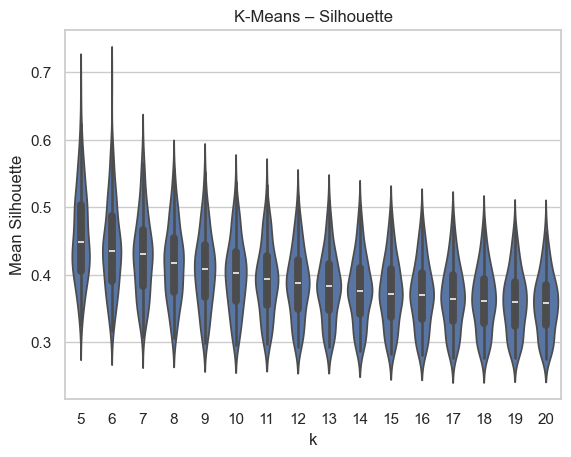

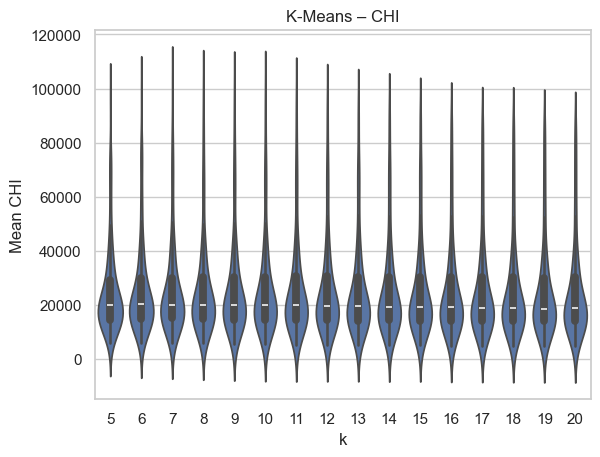

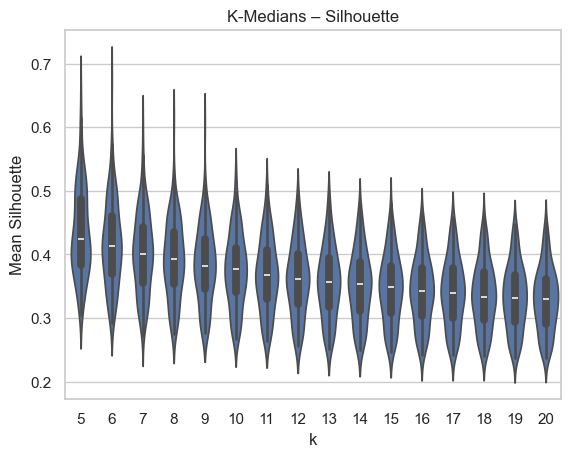

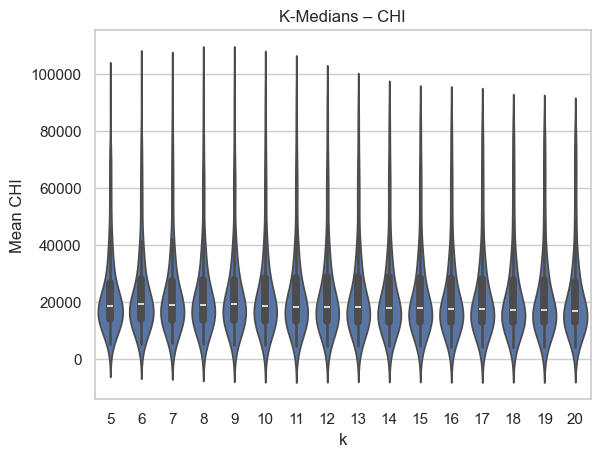

In [255]:
import seaborn as sns
import matplotlib.pyplot as plt

algorithms = df_results['Algorithm'].unique()

for i, algo in enumerate(algorithms):
    df_algo = df_results[df_results['Algorithm'] == algo]
    
    # --- SILHOUETTE ---
    plt.figure()
    sns.violinplot(data=df_algo, x='k', y='Mean_Silhouette')
    plt.title(f'{algo} – Silhouette')
    plt.xlabel('k')
    plt.ylabel('Mean Silhouette')
    plt.show()
    
    # --- CHI ---
    plt.figure()
    sns.violinplot(data=df_algo, x='k', y='Mean_CHI')
    plt.title(f'{algo} – CHI')
    plt.xlabel('k')
    plt.ylabel('Mean CHI')
    plt.show()


Based on the evaluation of both Silhouette and Calinski-Harabasz Index metrics, $k=5$ is the optimal number of clusters for this dataset. Both metrics achieve their peak median scores at $k=5$ and strictly decline thereafter, meaning that at this number, the colors inside each group are similar, and the groups themselves are distinctly different from one another.

In [40]:
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

In [41]:
uni = images_pixels['file'].unique()
best_k = 5
for i, image in enumerate(uni):
    print(f"Processing {image}...")
    mask = images_pixels['file'] == image

    # --- K-Means ---
    X_rgb = images_pixels.loc[mask, ['R', 'G', 'B']].values
    
    model_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
    model_kmeans.fit(X_rgb)
    
    palette_kmeans = model_kmeans.cluster_centers_.astype('uint8')
    new_colors_array_rgb = palette_kmeans[model_kmeans.labels_]
    images_pixels.loc[mask, 'newR_kmeans'] = new_colors_array_rgb[:, 0]
    images_pixels.loc[mask, 'newG_kmeans'] = new_colors_array_rgb[:, 1]
    images_pixels.loc[mask, 'newB_kmeans'] = new_colors_array_rgb[:, 2]

    # --- K-Medians ---
    model_kmed = KMedoids(n_clusters=best_k, random_state=1104, metric='manhattan', init='k-medoids++')
    model_kmed.fit(X_rgb)

    palette_kmed = model_kmed.cluster_centers_.astype('uint8')
    new_colors_array_kmed = palette_kmed[model_kmed.labels_]
    images_pixels.loc[mask, 'newR_kmed'] = new_colors_array_kmed[:, 0]
    images_pixels.loc[mask, 'newG_kmed'] = new_colors_array_kmed[:, 1]
    images_pixels.loc[mask, 'newB_kmed'] = new_colors_array_kmed[:, 2]

Processing kwiatek-76.png...
Processing kwiatek-62.png...
Processing kotek-7.png...
Processing kwiatek-1.png...
Processing kotek-14.png...
Processing kotek-28.png...
Processing kotek-29.png...
Processing kotek-15.png...
Processing kwiatek-0.png...
Processing kotek-6.png...
Processing kwiatek-63.png...
Processing kwiatek-49.png...
Processing kwiatek-61.png...
Processing kwiatek-75.png...
Processing kotek-4.png...
Processing kwiatek-2.png...
Processing kotek-17.png...
Processing kotek-16.png...
Processing kwiatek-3.png...
Processing kotek-5.png...
Processing kwiatek-74.png...
Processing kwiatek-60.png...
Processing kwiatek-48.png...
Processing kwiatek-64.png...
Processing kwiatek-70.png...
Processing kwiatek-58.png...
Processing kotek-1.png...
Processing kwiatek-7.png...
Processing kotek-12.png...
Processing kotek-13.png...
Processing kwiatek-6.png...
Processing kotek-0.png...
Processing kwiatek-59.png...
Processing kwiatek-71.png...
Processing kwiatek-65.png...
Processing kwiatek-73.png

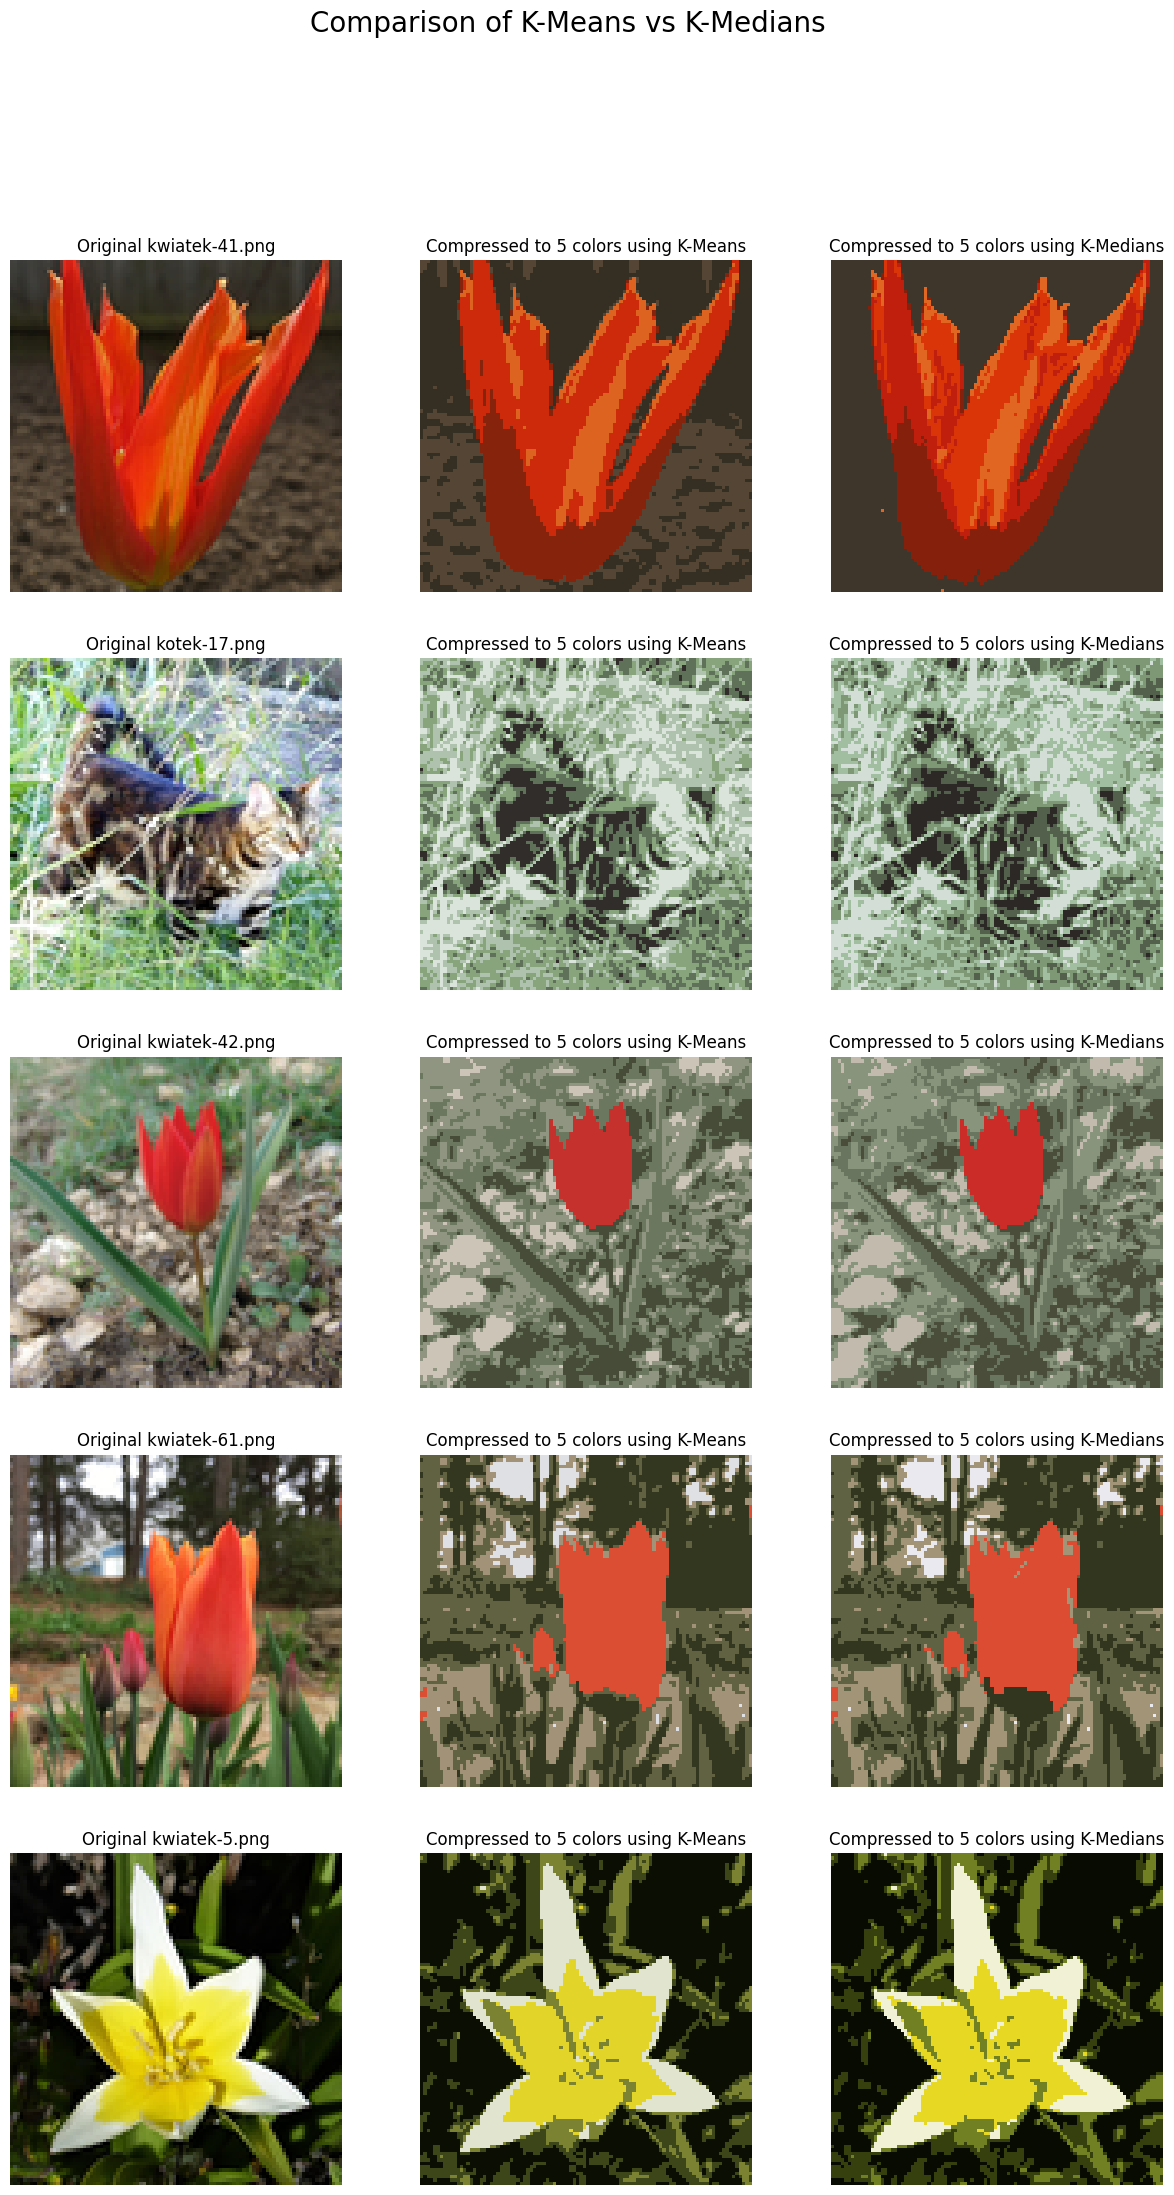

In [44]:
random_indices = np.random.choice(len(uni), size=5, replace=False)
ims = uni[random_indices]

fig, axes = plt.subplots(5, 3, figsize=(15, 25))
for i, image in enumerate(ims):
    mask = images_pixels['file'] == image
    width = height = 100
    test_image_new_colors_kmeans = np.zeros((height, width, 3), dtype=np.uint8)
    test_image_new_colors_kmeans[pixels['y'], pixels['x'], 0] = images_pixels.loc[mask, 'newR_kmeans']
    test_image_new_colors_kmeans[pixels['y'], pixels['x'], 1] = images_pixels.loc[mask, 'newG_kmeans']
    test_image_new_colors_kmeans[pixels['y'], pixels['x'], 2] = images_pixels.loc[mask, 'newB_kmeans']

    test_image_new_colors_kmed = np.zeros((height, width, 3), dtype=np.uint8)
    test_image_new_colors_kmed[pixels['y'], pixels['x'], 0] = images_pixels.loc[mask, 'newR_kmed']
    test_image_new_colors_kmed[pixels['y'], pixels['x'], 1] = images_pixels.loc[mask, 'newG_kmed']
    test_image_new_colors_kmed[pixels['y'], pixels['x'], 2] = images_pixels.loc[mask, 'newB_kmed']


    test_image_photo = Image.open(f'cat-flower/{image}').convert('RGB')

    axes[i, 0].imshow(test_image_photo)
    axes[i, 0].set_title(f"Original {image}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(test_image_new_colors_kmeans)
    axes[i, 1].set_title(f"Compressed to {best_k} colors using K-Means")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(test_image_new_colors_kmed)
    axes[i, 2].set_title(f"Compressed to {best_k} colors using K-Medians")
    axes[i, 2].axis('off')

fig.suptitle('Comparison of K-Means vs K-Medians', fontsize=20)
plt.show()

There is very little visual difference between the images reconstructed after K-Means and K-Medians training. However, looking at the violin plots from before, we can see that the median values for the Silhouette score are slightly higher for K-Means. It is also more efficient computationally.

Therefore, I will be using the K-Means training results from now on.

# Task 4
Objective: evaluate compression profits.

Saving compressed images in compressed/ folder

In [294]:
for image in uni:
    pixels = images_pixels[images_pixels['file'] == image].copy()
    width = height = 100
    new_image = np.zeros((height, width, 3), dtype=np.uint8)
    new_image[pixels['y'], pixels['x'], 0] = pixels['newR_kmeans']
    new_image[pixels['y'], pixels['x'], 1] = pixels['newG_kmeans']
    new_image[pixels['y'], pixels['x'], 2] = pixels['newB_kmeans']
    new_image = Image.fromarray(new_image)
    new_image.save(f'compressed/{image}', format='PNG')

Calculating profits from compresion using $\frac{\text{original size}- \text{compressed size}}{\text{original size}} \cdot 100$ formula

In [295]:
profits = {}
for image in uni:
    path_compressed = f'compressed/{image}'
    path_original = f'cat-flower/{image}'

    size_compressed = os.path.getsize(path_compressed) / 1024
    size_original = os.path.getsize(path_original) / 1024
    compression_profit = (size_original - size_compressed) / size_original * 100
    profits[image] = round(compression_profit, 2)


In [296]:
title_profits = f"""<h3 style="font-family: sans-serif;">Compression Profits for each image:</h3>
"""
display(HTML(title_profits))
idk_how_to_name_this = images_colors.copy()

idk_how_to_name_this['profit_percent'] = idk_how_to_name_this['file'].map(profits)

display(idk_how_to_name_this)


,file,unique_colors,profit_percent
0,kotek-0.png,9177,79.98
1,kotek-1.png,9151,82.24
2,kotek-10.png,7918,93.60
3,kotek-11.png,8913,82.43
4,kotek-12.png,9648,84.61
...,...,...,...
127,kwiatek-74.png,5707,84.95
128,kwiatek-75.png,9795,81.59
129,kwiatek-76.png,9481,83.82
130,kwiatek-8.png,7893,89.13


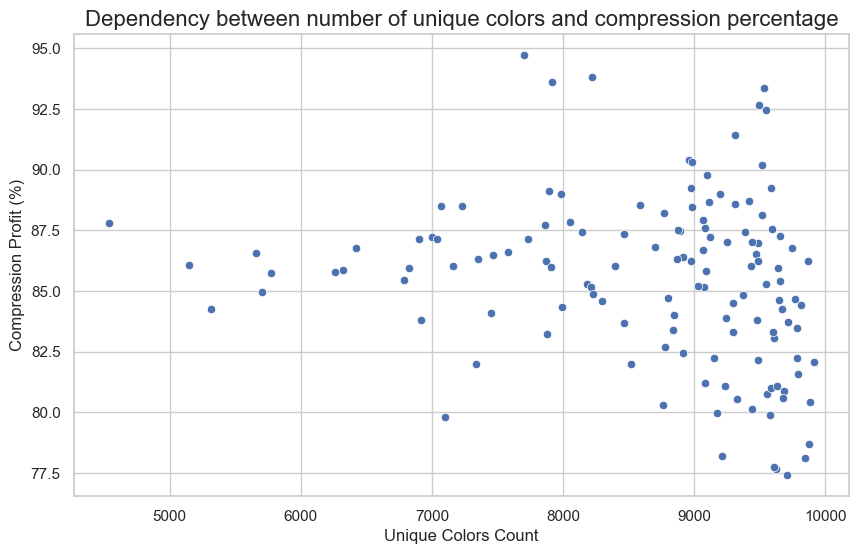

In [297]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=idk_how_to_name_this, x='unique_colors', y='profit_percent')
plt.title('Dependency between number of unique colors and compression percentage', fontsize=16)
plt.xlabel('Unique Colors Count', fontsize=12)
plt.ylabel('Compression Profit (%)', fontsize=12)
plt.grid(True)
plt.show()

In [298]:
from sklearn.linear_model import LinearRegression

X = idk_how_to_name_this[['unique_colors']]
y = idk_how_to_name_this['profit_percent']

model_lin = LinearRegression().fit(X, y)
r2_lin = model_lin.score(X, y)
print(f"R2 for linear model: {r2_lin:.4f}")

X_log = np.log(X)
model_log = LinearRegression().fit(X_log, y)
r2_log = model_log.score(X_log, y)
print(f"R2 for logarithmic model: {r2_log:.4f}")


X_reciprocal = 1 / X

model_odw = LinearRegression().fit(X_reciprocal, y)
r2_odw = model_odw.score(X_reciprocal, y)
print(f"R2 for reciprocal model: {r2_odw:.4f}")


X_quadratic = X.copy()
X_quadratic['unique_colors_sq'] = X['unique_colors'] ** 2

model_quad = LinearRegression().fit(X_quadratic, y)
r2_quad = model_quad.score(X_quadratic, y)
print(f"R2 for quadratic model: {r2_quad:.4f}")

R2 for linear model: 0.0428
R2 for logarithmic model: 0.0350
R2 for reciprocal model: 0.0275
R2 for quadratic model: 0.0889


Best performing model is the one with quadratic function form

In [299]:
print(f"Best profit prediction: y = {model_quad.coef_[1]:.8f} * x^2 + {model_quad.coef_[0]:.8f} * x + {model_quad.intercept_:.8f}")


Best profit prediction: y = -0.00000046 * x^2 + 0.00656749 * x + 63.37986709


# Task 5
Objective: Compare models identifying cats from original and compressed images.

In [301]:
y = []
X_orig = []
X_comp = []
for image in uni:
    y.append(1 if image.startswith('kotek') else 0)
    orig = images_pixels[images_pixels['file'] == image][['R', 'G', 'B']].apply(lambda row: (row['R'] + row['G']*256 + row['B']*256**2), axis=1).tolist()
    X_orig.append(orig)
    comp = images_pixels[images_pixels['file'] == image][['newR_kmeans', 'newG_kmeans', 'newB_kmeans']].apply(lambda row: (row['newR_kmeans'] + row['newG_kmeans']*256 + row['newB_kmeans']*256**2), axis=1).tolist()
    X_comp.append(comp)
print(np.array(X_comp).shape)

(132, 10000)


In [327]:
from sklearn.model_selection import train_test_split
X_orig_train, X_orig_test, y_train, y_test = train_test_split(X_orig, y, test_size=0.1, random_state=48, stratify=y)
X_comp_train, X_comp_test, y_comp_train, y_comp_test = train_test_split(X_comp, y, test_size=0.1, random_state=48, stratify=y)

In [328]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

param_grid = {'n_neighbors': range(1, 26)}

knn_orig = KNeighborsClassifier()
grid_orig = GridSearchCV(knn_orig, param_grid, cv=5, scoring='f1')

grid_orig.fit(X_orig_train, y_train)

best_knn_orig = grid_orig.best_estimator_

f1_val_orig = grid_orig.best_score_
f1_train_orig = f1_score(y_train, best_knn_orig.predict(X_orig_train))
f1_test_orig = f1_score(y_test, best_knn_orig.predict(X_orig_test))

knn_comp = KNeighborsClassifier()
grid_comp = GridSearchCV(knn_comp, param_grid, cv=5, scoring='f1')

grid_comp.fit(X_comp_train, y_comp_train)

best_knn_comp = grid_comp.best_estimator_

f1_val_comp = grid_comp.best_score_ 
f1_train_comp = f1_score(y_comp_train, best_knn_comp.predict(X_comp_train))
f1_test_comp = f1_score(y_comp_test, best_knn_comp.predict(X_comp_test))

In [329]:
print("========= F1 Scores: =========\n")

print(f"ORIGINAL IMAGES (Best k = {grid_orig.best_params_['n_neighbors']})")
print(f"Train:      {f1_train_orig:.4f}")
print(f"Validation: {f1_val_orig:.4f}")
print(f"Test:       {f1_test_orig:.4f}")

print(f"\nCOMPRESSED IMAGES (Best k = {grid_comp.best_params_['n_neighbors']})")
print(f"Train:      {f1_train_comp:.4f}")
print(f"Validation: {f1_val_comp:.4f}")
print(f"Test:       {f1_test_comp:.4f}")

========= F1 Scores: =========

ORIGINAL IMAGES (Best k = 19)
Train:      0.6909
Validation: 0.6843
Test:       0.6667

COMPRESSED IMAGES (Best k = 15)
Train:      0.6852
Validation: 0.6403
Test:       0.7143


Overall, the K-Means color compression performed well. Although the training and validation F1 scores decreased slightly—suggesting that some color information used by the kNN model was lost during compression—the impact was very small. The unusually high test score of the compressed model, which even exceeds the training score, may seem questionable at first, but it can be reasonably explained. Since the dataset is relatively small and the test set makes up only 10% of the data, the test results are quite unstable and strongly influenced by the particular images that happened to be included in the split.